# Modelos predictores de Implied Volatility







El **objetivo** de este notebook es aplicar diversos modelos y técnicas de IA y RRNN para encontrar el mejor modelo capaz de hacer una predicción con el mínimo error de la Volatilidad Implícita de trades de opciones del IBEX 35.

In [1]:
from src.volatility_models.data_utils import TrainingDataHandler

from src.volatility_models.training_utils import Trainer
from src.python_models.volatility_models.volatility_model_family import (
    LinearRegressionFamily,
    RandomForestFamily,
    XGBoostFamily,
    SequentialNNFamily,
    QuantumInspiredNNFamily,
)
from src.python_models.volatility_models.volatility_model_family import TrainingPhase

## Selección de variables, Splits y  Feature Engineering

In [2]:
# Columnas escogidas para features + target + auditoría
volatility_df = TrainingDataHandler.load_volatility_db()
print("Rows loaded:", len(volatility_df))
display(volatility_df.head())

Rows loaded: 314873


,ExecDatetime,OptionContractCode,OptionType,Quantity,StrikePrice,TradeType,UnderlyingLagMinutes,UnderlyingPrice,TimeToExpiration,Rate,ImpliedVolatility
0,2017-01-02 09:13:43,CIBX 9600F17,C,3,9600.0,M,0.433333,9305.0,18.344641,-0.500415,0.175113
1,2017-01-02 09:23:09,PIBX 8200F17,P,5000,8200.0,H,0.1,9314.0,18.338091,-0.500594,0.265431
2,2017-01-02 09:24:08,CIBX 9300F17,C,1,9300.0,M,0.816667,9314.0,18.337408,-0.500612,0.189698
3,2017-01-02 09:29:21,PIBX 8500F17,P,5000,8500.0,H,0.333333,9322.0,18.333784,-0.500711,0.243136
4,2017-01-02 09:32:52,CIBX 9400F17,C,1,9400.0,M,0.0,9331.0,18.331343,-0.500778,0.185166


Adicionalmente, hay que crear un catálogo de las variables categóricas porque hay que aplicarle one-hot encoding.

In [3]:
train_df, val_df, test_df = TrainingDataHandler.load_splitted_data()

2026-04-18 13:11:10,993 | INFO | src.volatility_models.data_utils | Contract-code leakage control applied | overlapping contracts: 156 | removed rows -> train: 462, val: 1253, test: 290
2026-04-18 13:11:11,036 | INFO | src.volatility_models.data_utils | ===============================================================================================
2026-04-18 13:11:11,036 | INFO | src.volatility_models.data_utils | SPLIT TEMPORAL INICIAL (sobre todo el dataset): Train / Valid / Test
2026-04-18 13:11:11,036 | INFO | src.volatility_models.data_utils | ===============================================================================================
2026-04-18 13:11:11,036 | INFO | src.volatility_models.data_utils | Total filas: 312,868 | Total fechas: 1,402
2026-04-18 13:11:11,036 | INFO | src.volatility_models.data_utils | Train | rows:  250,465 ( 80.05%) | dates: 1,012 ( 72.18%) | range: 2017-01-02 -> 2020-12-17
2026-04-18 13:11:11,041 | INFO | src.volatility_models.data_utils | Valid | ro

In [4]:
# Seleccionamos columnas finales
train_df, val_df, test_df = TrainingDataHandler.load_full_features_splitted_data()
print(f"Total rows adding up all dataframes: {len(train_df)+len(val_df)+len(test_df)}")

2026-04-18 13:11:13,187 | INFO | src.volatility_models.data_utils | Contract-code leakage control applied | overlapping contracts: 156 | removed rows -> train: 462, val: 1253, test: 290
2026-04-18 13:11:13,242 | INFO | src.volatility_models.data_utils | ===============================================================================================
2026-04-18 13:11:13,242 | INFO | src.volatility_models.data_utils | SPLIT TEMPORAL INICIAL (sobre todo el dataset): Train / Valid / Test
2026-04-18 13:11:13,242 | INFO | src.volatility_models.data_utils | ===============================================================================================
2026-04-18 13:11:13,242 | INFO | src.volatility_models.data_utils | Total filas: 312,868 | Total fechas: 1,402
2026-04-18 13:11:13,242 | INFO | src.volatility_models.data_utils | Train | rows:  250,465 ( 80.05%) | dates: 1,012 ( 72.18%) | range: 2017-01-02 -> 2020-12-17
2026-04-18 13:11:13,242 | INFO | src.volatility_models.data_utils | Valid | ro

Total rows adding up all dataframes: 312868


In [5]:
folds = TrainingDataHandler.load_kfolds()

2026-04-18 13:11:21,605 | INFO | src.volatility_models.data_utils | 
2026-04-18 13:11:21,612 | INFO | src.volatility_models.data_utils | K-FOLDS TEMPORALES (solo dentro de Train) para validación por familia de modelos
2026-04-18 13:11:21,612 | INFO | src.volatility_models.data_utils | ===============================================================================================
2026-04-18 13:11:21,612 | INFO | src.volatility_models.data_utils | Train global -> filas: 250,465 | fechas: 1,012
2026-04-18 13:11:21,627 | INFO | src.volatility_models.data_utils | FOLD-1
2026-04-18 13:11:21,627 | INFO | src.volatility_models.data_utils |   TRAIN | rows:   94,944 ( 37.91% de train) | dates:   309 ( 30.53% de train) | range: 2017-01-02 -> 2018-03-19
2026-04-18 13:11:21,628 | INFO | src.volatility_models.data_utils |   VALID | rows:   12,401 (  4.95% de train) | dates:    55 (  5.43% de train) | range: 2018-03-20 -> 2018-06-07
2026-04-18 13:11:21,655 | INFO | src.volatility_models.data_utils | 

# Fase CV

Entrenando familia: linear_regression: 100%|██████████| 1/1 [00:00<00:00,  1.88it/s]
2026-04-18 13:11:34,818 | INFO | src.volatility_models.visualization_utils | Mostrando top 15 modelos de la familia
                   custom_error1  train_mae  train_rmse  train_r2   val_mae  val_rmse   val_r2  train_mae_std  train_rmse_std  train_r2_std  val_mae_std  val_rmse_std  val_r2_std
linear_regression       0.148402   0.040161    0.100073  0.252892  0.056418  0.120179 -0.15725        0.00732        0.018249       0.04526     0.019408      0.052575    0.195608


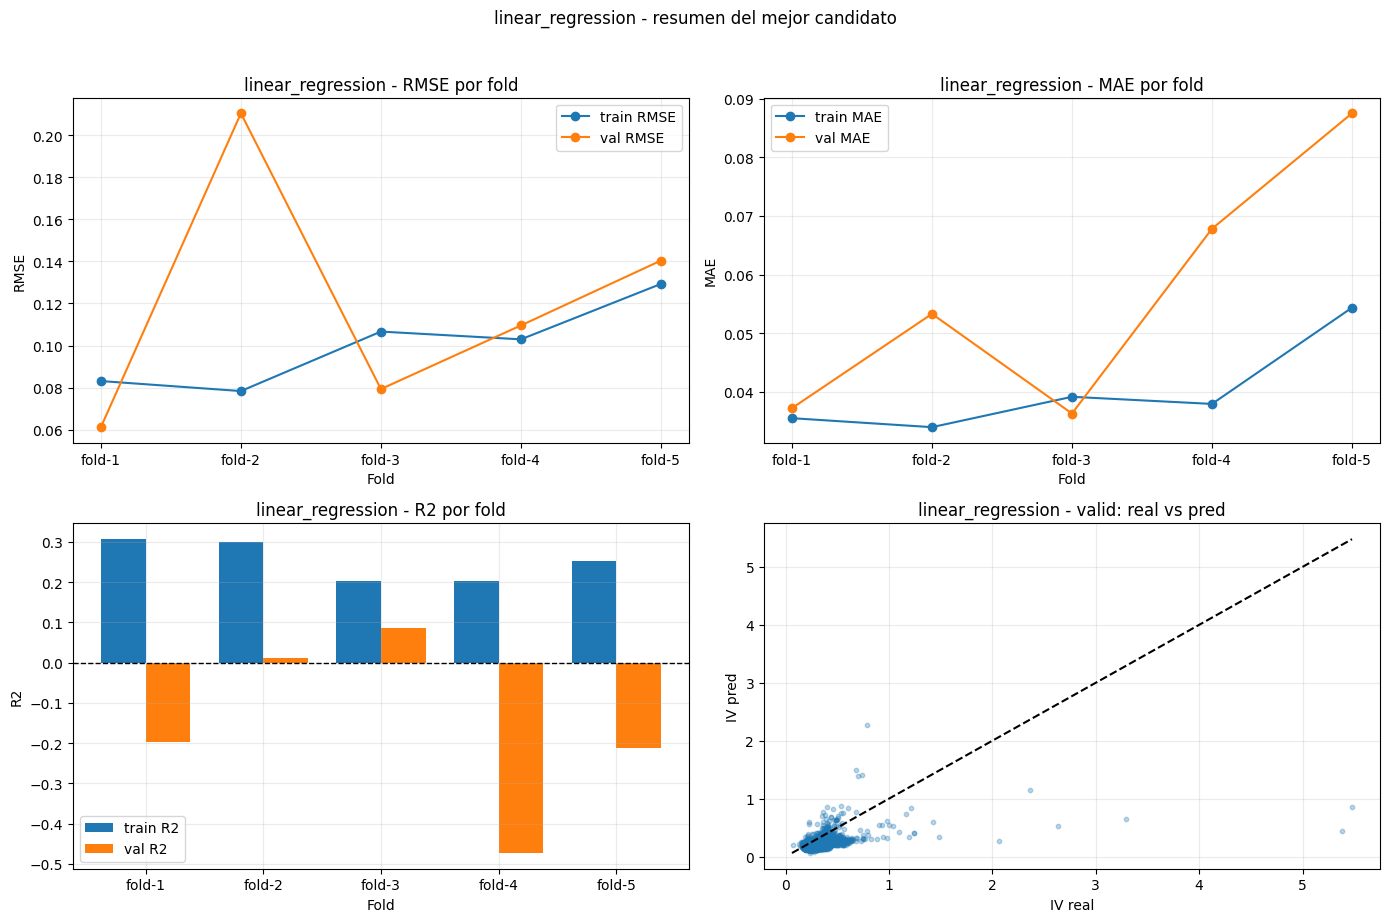

2026-04-18 13:11:35,501 | INFO | src.volatility_models.visualization_utils | Metadata guardada: C:\Users\danir\Desktop\TFM - Opciones\options-pricing\src\volatility_models\trained_metadata\family_metadata\linear_regression_metadata.json


In [6]:
linear_models_metrics_table, linear_best_model_name = Trainer(LinearRegressionFamily).run_kfolds_training()

Entrenando familia: random_forest: 100%|██████████| 1/1 [01:53<00:00, 113.08s/it]
2026-04-18 13:13:33,965 | INFO | src.volatility_models.visualization_utils | Mostrando top 15 modelos de la familia
                   custom_error1  train_mae  train_rmse  train_r2   val_mae  val_rmse    val_r2  train_mae_std  train_rmse_std  train_r2_std  val_mae_std  val_rmse_std  val_r2_std
random_forest_001        0.11278   0.024245    0.041193   0.87402  0.041136  0.075924  0.567467       0.004425          0.0117      0.032446     0.017903       0.04323    0.149217


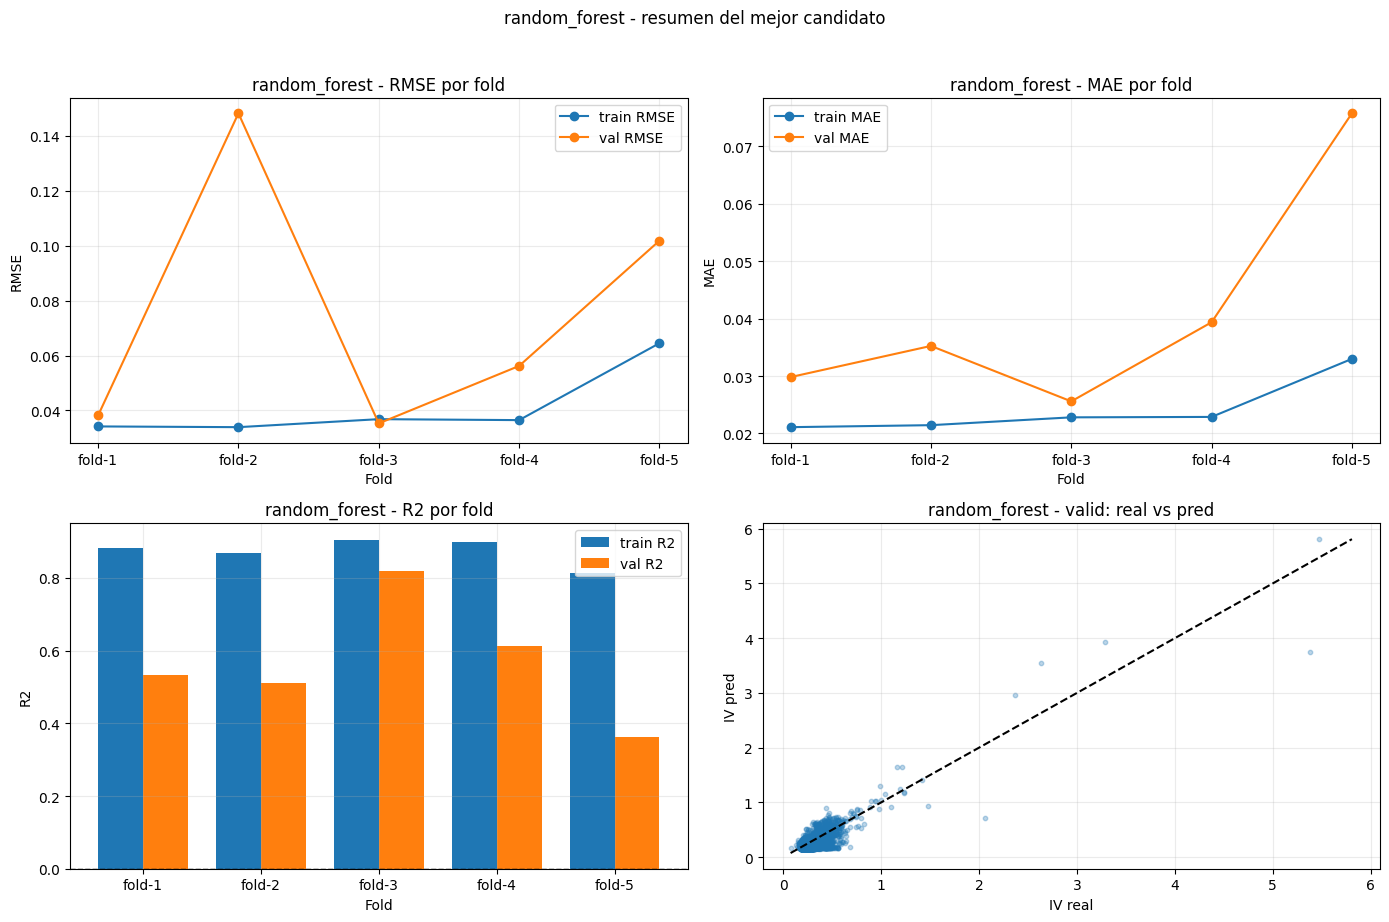

2026-04-18 13:13:34,508 | INFO | src.volatility_models.visualization_utils | Metadata guardada: C:\Users\danir\Desktop\TFM - Opciones\options-pricing\src\volatility_models\trained_metadata\family_metadata\random_forest_metadata.json


In [7]:
random_forest_models_metrics_table, random_forest_best_model_name = Trainer(RandomForestFamily).run_kfolds_training()

Entrenando familia: xgboost: 100%|██████████| 1/1 [00:17<00:00, 17.45s/it]
2026-04-18 13:13:57,663 | INFO | src.volatility_models.visualization_utils | Mostrando top 15 modelos de la familia
             custom_error1  train_mae  train_rmse  train_r2   val_mae  val_rmse    val_r2  train_mae_std  train_rmse_std  train_r2_std  val_mae_std  val_rmse_std  val_r2_std
xgboost_001       0.109712     0.0227    0.046288  0.841152  0.045701  0.076426  0.544455       0.005114        0.019156      0.077987     0.027707      0.042731    0.222353


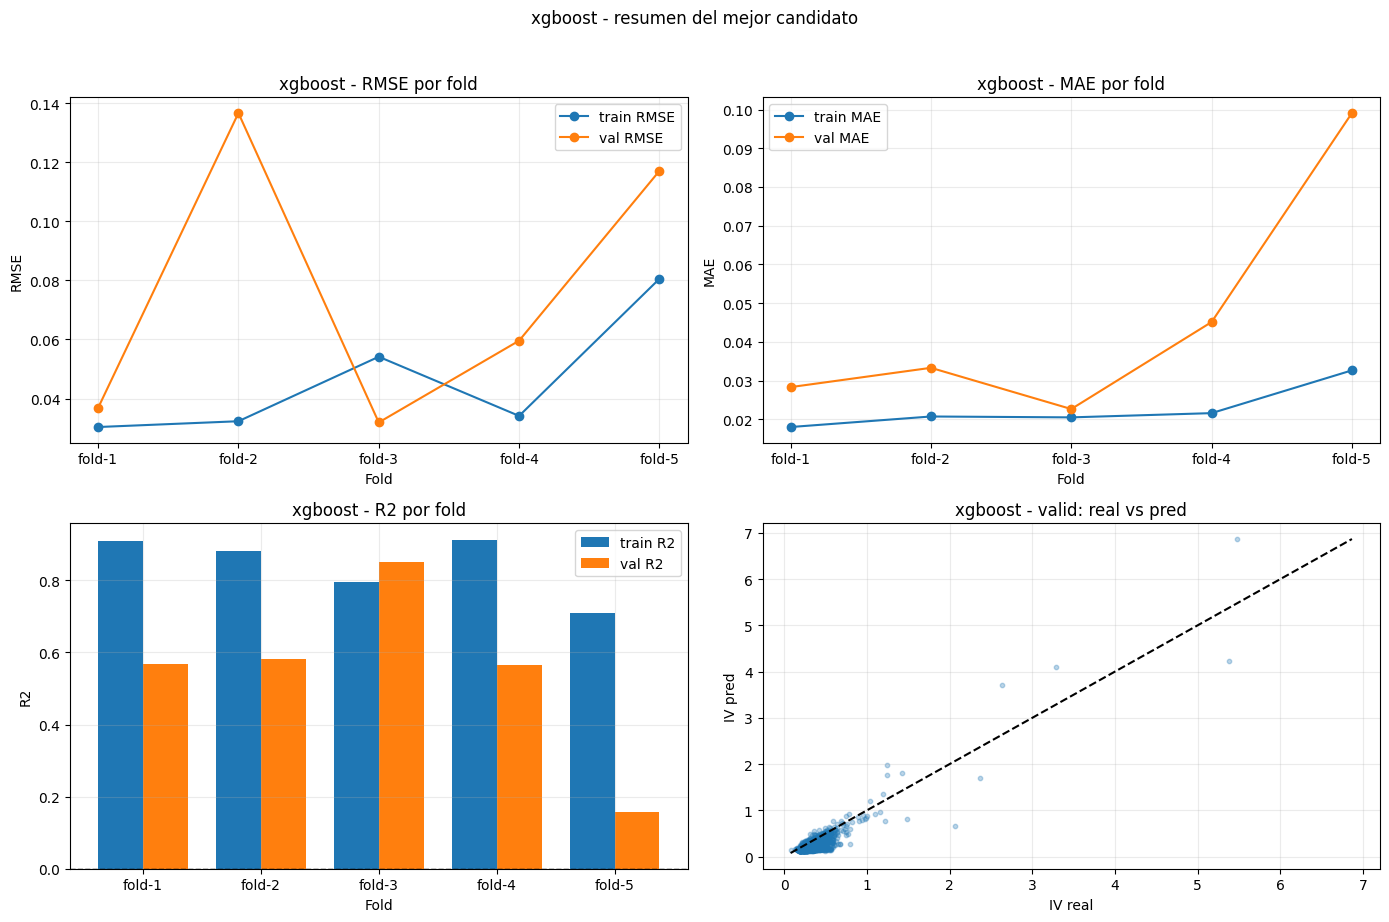

2026-04-18 13:13:58,341 | INFO | src.volatility_models.visualization_utils | Metadata guardada: C:\Users\danir\Desktop\TFM - Opciones\options-pricing\src\volatility_models\trained_metadata\family_metadata\xgboost_metadata.json


In [8]:
xgboost_models_metrics_table, xgboost_best_model_name = Trainer(XGBoostFamily).run_kfolds_training()

Entrenando familia: sequential_nn:   0%|          | 0/1 [00:00<?, ?it/s]2026-04-18 13:14:04,225 | WARNING | tensorflow | From c:\Users\danir\Desktop\TFM - Opciones\options-pricing\tfmenv\Lib\site-packages\keras\src\backend\common\global_state.py:82: The name tf.reset_default_graph is deprecated. Please use tf.compat.v1.reset_default_graph instead.

2026-04-18 13:14:04,452 | WARNING | tensorflow | TensorFlow GPU support is not available on native Windows for TensorFlow >= 2.11. Even if CUDA/cuDNN are installed, GPU will not be used. Please use WSL2 or the TensorFlow-DirectML plugin.
Entrenando familia: sequential_nn: 100%|██████████| 1/1 [01:33<00:00, 93.85s/it]
2026-04-18 13:15:37,609 | INFO | src.volatility_models.visualization_utils | Mostrando top 15 modelos de la familia
                   custom_error1  train_mae  train_rmse  train_r2   val_mae  val_rmse    val_r2  train_mae_std  train_rmse_std  train_r2_std  val_mae_std  val_rmse_std  val_r2_std
sequential_nn_001       0.134749  

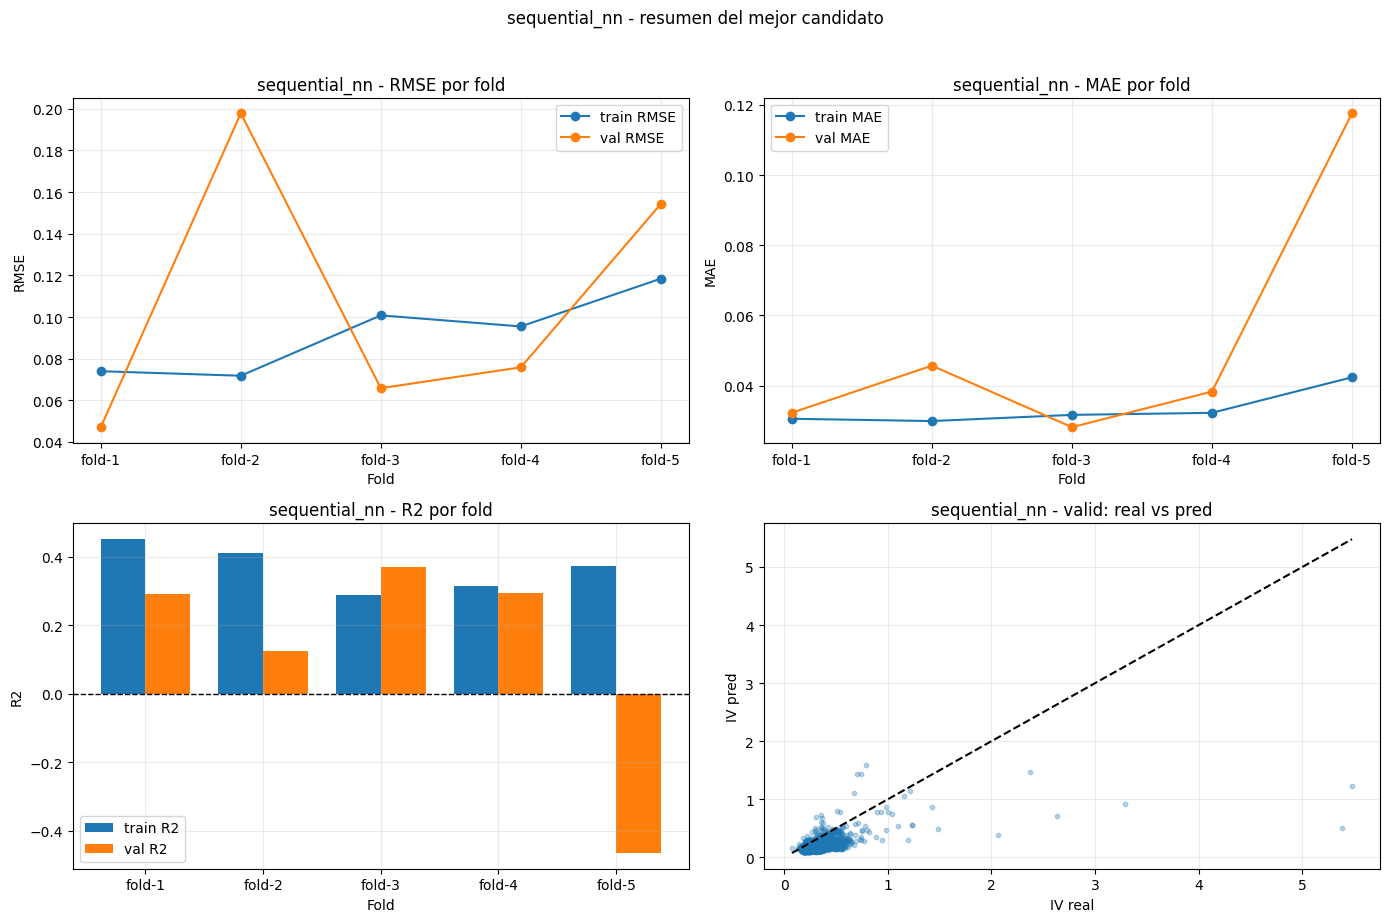

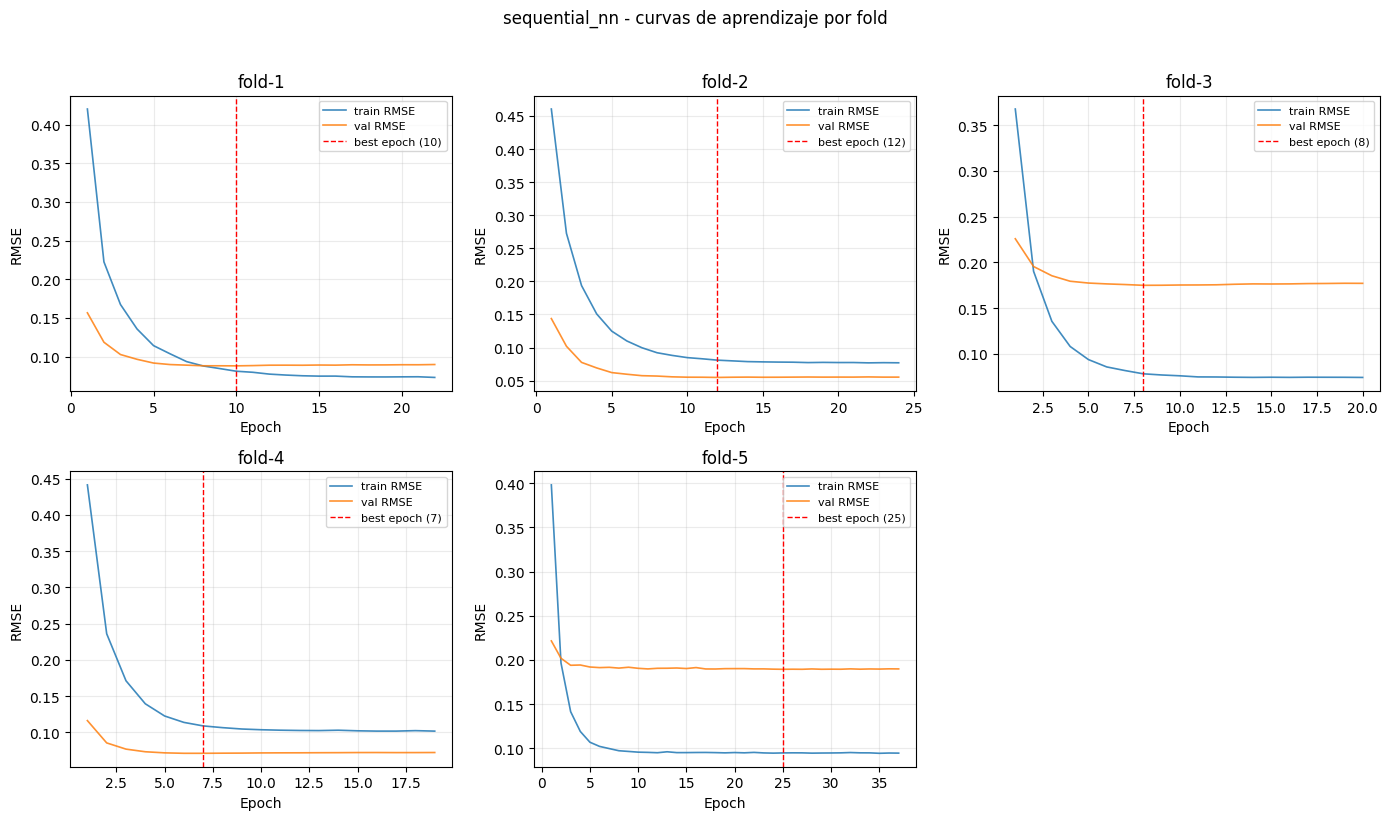

2026-04-18 13:15:38,530 | INFO | src.volatility_models.visualization_utils | Metadata guardada: C:\Users\danir\Desktop\TFM - Opciones\options-pricing\src\volatility_models\trained_metadata\family_metadata\sequential_nn_metadata.json


In [9]:
sequential_nn_models_metrics_table, sequential_nn_best_model_name = Trainer(SequentialNNFamily).run_kfolds_training()

In [ ]:
# Autokeras
sequential_nn_models_metrics_table, sequential_nn_best_model_name = Trainer(SequentialNNFamily).run_kfolds_training()

Entrenando familia: quantum_inspired_nn: 100%|██████████| 1/1 [04:24<00:00, 264.48s/it]
2026-04-18 13:20:08,443 | INFO | src.volatility_models.visualization_utils | Mostrando top 15 modelos de la familia
                         custom_error1  train_mae  train_rmse  train_r2   val_mae  val_rmse    val_r2  train_mae_std  train_rmse_std  train_r2_std  val_mae_std  val_rmse_std  val_r2_std
quantum_inspired_nn_001       0.144175   0.030897    0.072735  0.595073  0.051669  0.104222  0.183585       0.007797        0.024272      0.161897     0.030608      0.065353    0.397027


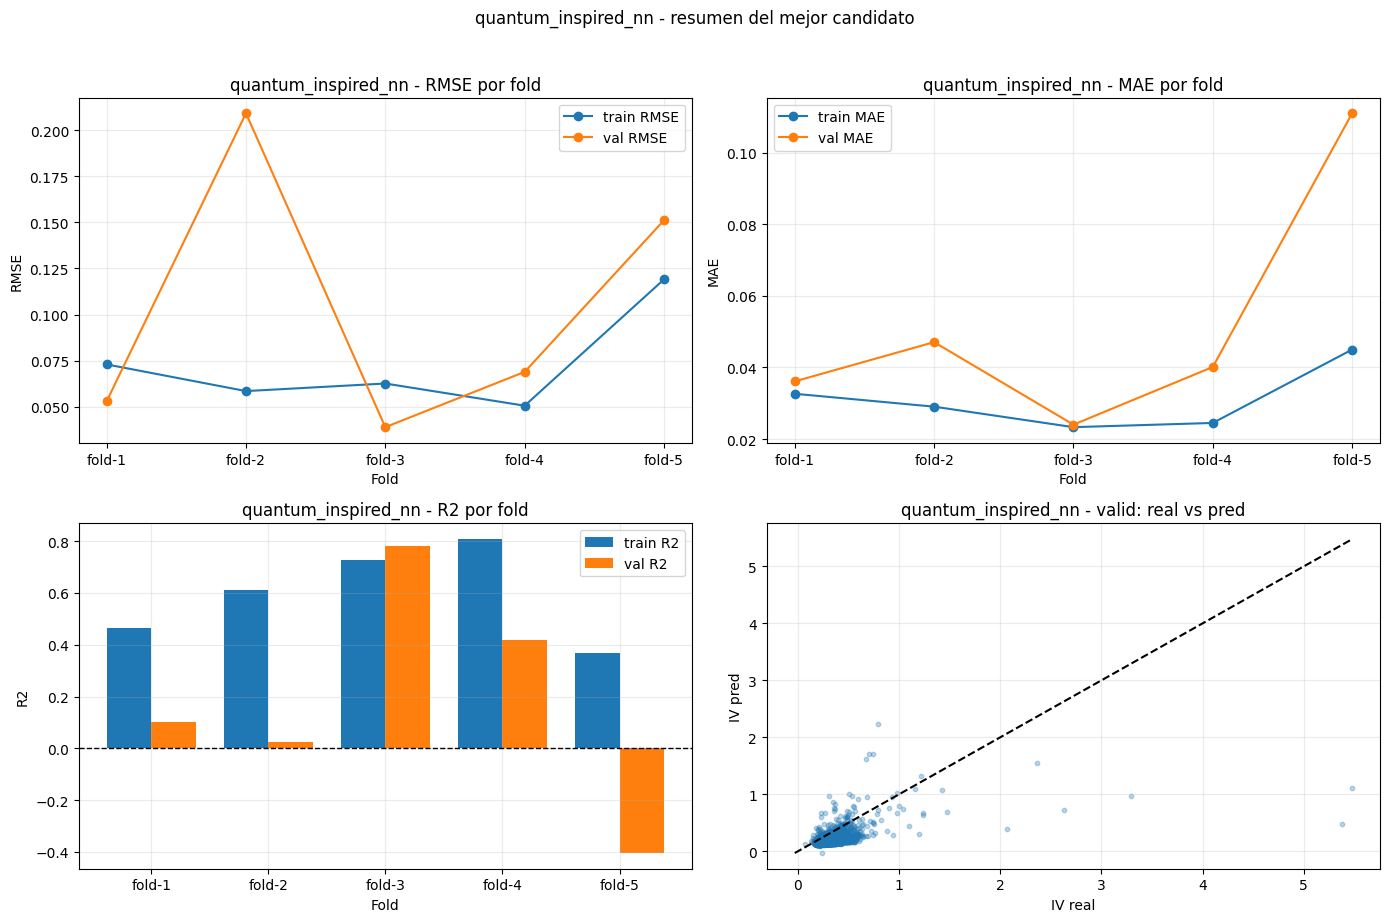

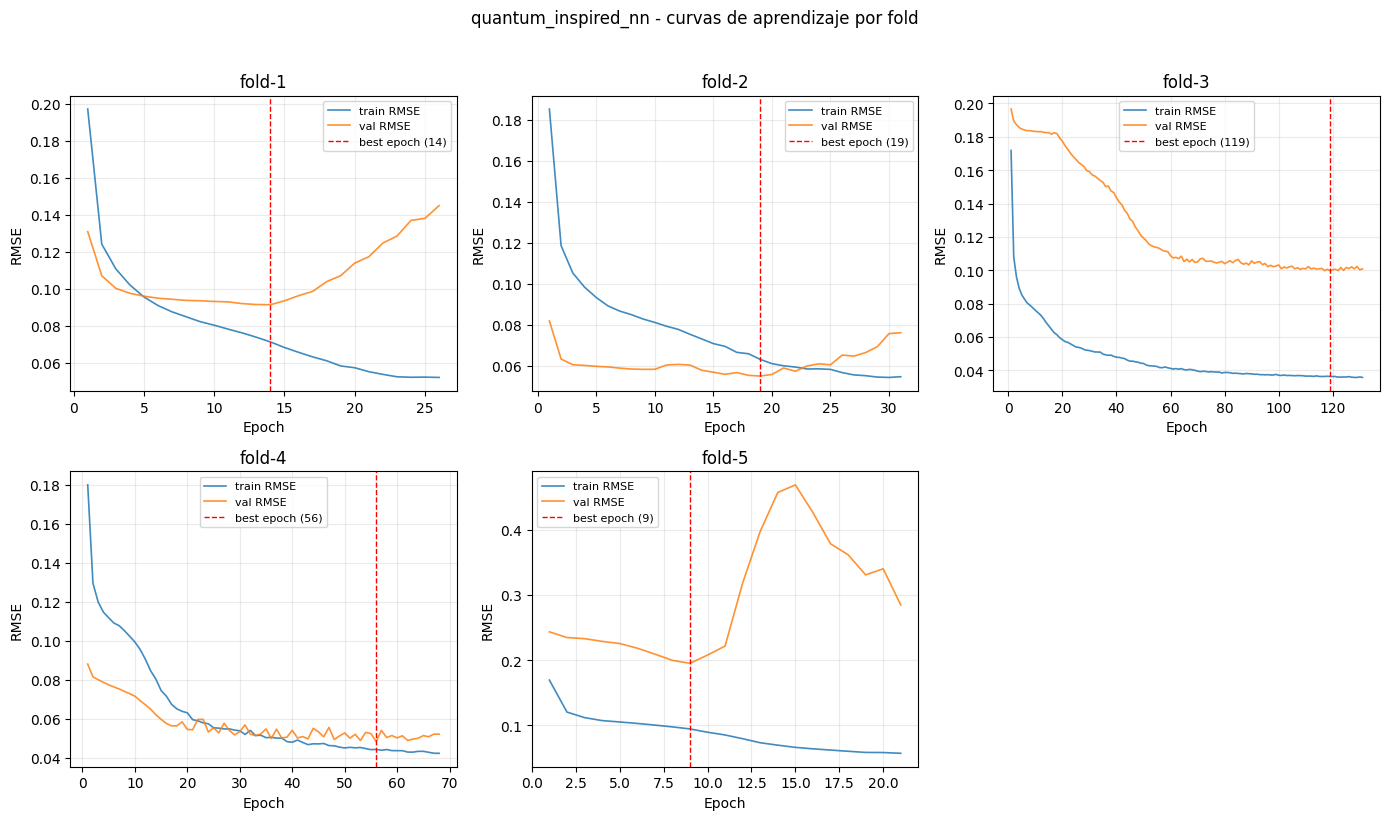

2026-04-18 13:20:09,331 | INFO | src.volatility_models.visualization_utils | Metadata guardada: C:\Users\danir\Desktop\TFM - Opciones\options-pricing\src\volatility_models\trained_metadata\family_metadata\quantum_inspired_nn_metadata.json


In [10]:
quantum_inspired_nn_models_metrics_table, quantum_inspired_nn_best_model_name = Trainer(QuantumInspiredNNFamily).run_kfolds_training()

# Reentrenamiento de la mejor parametrización de cada familia

In [2]:
linear_best_model_metrics = Trainer(LinearRegressionFamily).retrain_best_params_family()

2026-04-18 13:26:52,036 | INFO | src.volatility_models.visualization_utils | Resultados del mejor modelo de la familia tras el reentrenamiento:
                custom_error2  train_mae  train_rmse  train_r2   val_mae  val_rmse    val_r2
retrained_best        0.18833   0.082839     0.16844 -0.254548  0.051715  0.151229 -0.471826
2026-04-18 13:26:52,103 | INFO | src.volatility_models.visualization_utils | Metadata de reentrenamiento guardada: C:\Users\danir\Desktop\TFM - Opciones\options-pricing\src\volatility_models\trained_metadata\retrained_metadata\linear_regression_train_val_retrained_metadata.json


In [3]:
random_forest_best_model_metrics = Trainer(RandomForestFamily).retrain_best_params_family()

2026-04-18 13:27:43,204 | INFO | src.volatility_models.visualization_utils | Resultados del mejor modelo de la familia tras el reentrenamiento:
                custom_error2  train_mae  train_rmse  train_r2   val_mae  val_rmse    val_r2
retrained_best       0.096002   0.084412    0.195844 -0.695949  0.042346  0.067807  0.704104
2026-04-18 13:27:43,265 | INFO | src.volatility_models.visualization_utils | Metadata de reentrenamiento guardada: C:\Users\danir\Desktop\TFM - Opciones\options-pricing\src\volatility_models\trained_metadata\retrained_metadata\random_forest_train_val_retrained_metadata.json


In [4]:
xgboost_best_model_metrics = Trainer(XGBoostFamily).retrain_best_params_family()

2026-04-18 13:27:55,693 | INFO | src.volatility_models.visualization_utils | Resultados del mejor modelo de la familia tras el reentrenamiento:
                custom_error2  train_mae  train_rmse  train_r2   val_mae  val_rmse    val_r2
retrained_best       0.102465   0.087897     0.20155 -0.796225  0.055554  0.075037  0.637643
2026-04-18 13:27:55,794 | INFO | src.volatility_models.visualization_utils | Metadata de reentrenamiento guardada: C:\Users\danir\Desktop\TFM - Opciones\options-pricing\src\volatility_models\trained_metadata\retrained_metadata\xgboost_train_val_retrained_metadata.json


2026-04-18 13:28:01,083 | WARNING | tensorflow | From c:\Users\danir\Desktop\TFM - Opciones\options-pricing\tfmenv\Lib\site-packages\keras\src\backend\common\global_state.py:82: The name tf.reset_default_graph is deprecated. Please use tf.compat.v1.reset_default_graph instead.

2026-04-18 13:28:01,229 | WARNING | tensorflow | TensorFlow GPU support is not available on native Windows for TensorFlow >= 2.11. Even if CUDA/cuDNN are installed, GPU will not be used. Please use WSL2 or the TensorFlow-DirectML plugin.
2026-04-18 13:28:51,400 | INFO | src.volatility_models.visualization_utils | Resultados del mejor modelo de la familia tras el reentrenamiento:
                custom_error2  train_mae  train_rmse  train_r2   val_mae  val_rmse    val_r2
retrained_best       0.138214   0.082943     0.17172 -0.303883  0.041442  0.104527  0.296852


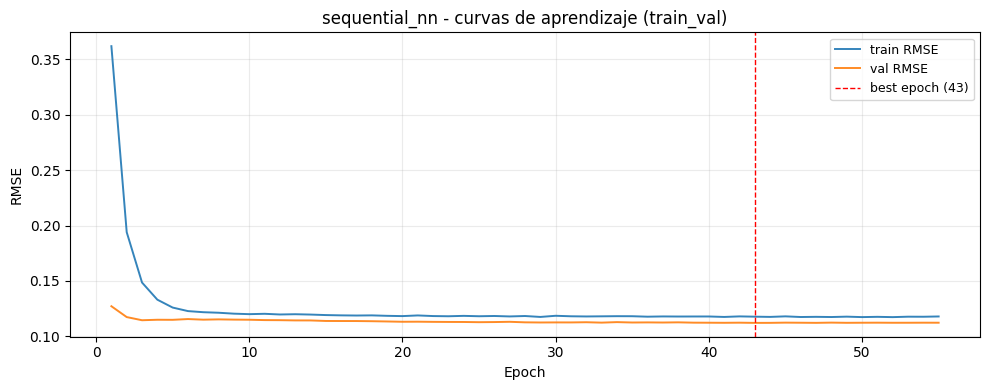

2026-04-18 13:28:51,544 | INFO | src.volatility_models.visualization_utils | Metadata de reentrenamiento guardada: C:\Users\danir\Desktop\TFM - Opciones\options-pricing\src\volatility_models\trained_metadata\retrained_metadata\sequential_nn_train_val_retrained_metadata.json


In [5]:
sequential_nn_best_model_metrics = Trainer(SequentialNNFamily).retrain_best_params_family()

In [ ]:
# Autokeras
sequential_nn_best_model_metrics = Trainer(SequentialNNFamily).retrain_best_params_family()

2026-04-18 13:30:30,231 | INFO | src.volatility_models.visualization_utils | Resultados del mejor modelo de la familia tras el reentrenamiento:
                custom_error2  train_mae  train_rmse  train_r2   val_mae  val_rmse    val_r2
retrained_best       0.288156   0.086262    0.197794 -0.729907  0.052883  0.228833 -2.369971


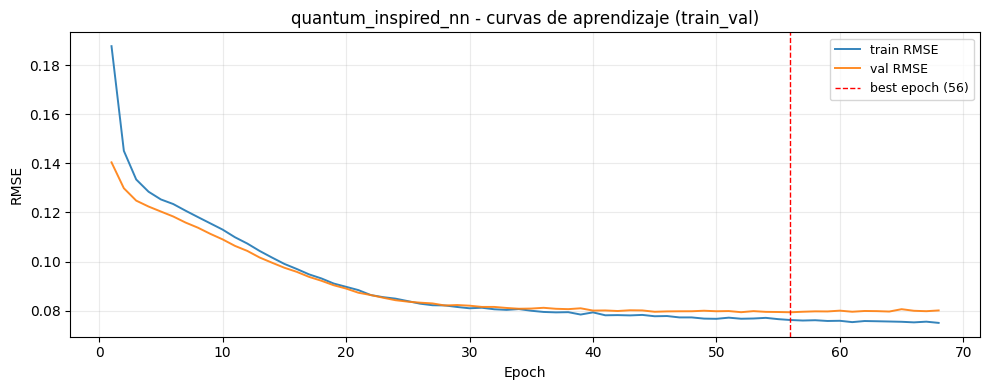

2026-04-18 13:30:30,359 | INFO | src.volatility_models.visualization_utils | Metadata de reentrenamiento guardada: C:\Users\danir\Desktop\TFM - Opciones\options-pricing\src\volatility_models\trained_metadata\retrained_metadata\quantum_inspired_nn_train_val_retrained_metadata.json


In [6]:
quantum_inspired_nn_best_model_metrics = Trainer(QuantumInspiredNNFamily).retrain_best_params_family()

# Reentrenamiento para posterior test

In [7]:
linear_best_model_metrics_test = Trainer(LinearRegressionFamily).retrain_best_params_family(phase=TrainingPhase.FINAL_TEST)

2026-04-18 13:30:35,252 | INFO | src.volatility_models.visualization_utils | Resultados del mejor modelo de la familia tras el reentrenamiento con train + val:
                train_mae  train_rmse  train_r2  test_mae  test_rmse   test_r2
retrained_best   0.080416     0.16552 -0.247175  0.071015   0.185628  0.080706
2026-04-18 13:30:35,338 | INFO | src.volatility_models.visualization_utils | Metadata de reentrenamiento guardada: C:\Users\danir\Desktop\TFM - Opciones\options-pricing\src\volatility_models\trained_metadata\retrained_metadata\linear_regression_final_test_retrained_metadata.json
2026-04-18 13:30:35,340 | INFO | src.volatility_models.visualization_utils | Modelo guardado en: C:\Users\danir\Desktop\TFM - Opciones\options-pricing\src\volatility_models\trained_models\linear_regression.joblib


In [8]:
random_forest_best_model_metrics_test = Trainer(RandomForestFamily).retrain_best_params_family(phase=TrainingPhase.FINAL_TEST)

2026-04-18 13:31:32,442 | INFO | src.volatility_models.visualization_utils | Resultados del mejor modelo de la familia tras el reentrenamiento con train + val:
                train_mae  train_rmse  train_r2  test_mae  test_rmse   test_r2
retrained_best    0.08279    0.192643 -0.689407  0.053784   0.088919  0.789063
2026-04-18 13:31:32,540 | INFO | src.volatility_models.visualization_utils | Metadata de reentrenamiento guardada: C:\Users\danir\Desktop\TFM - Opciones\options-pricing\src\volatility_models\trained_metadata\retrained_metadata\random_forest_final_test_retrained_metadata.json
2026-04-18 13:31:32,586 | INFO | src.volatility_models.visualization_utils | Modelo guardado en: C:\Users\danir\Desktop\TFM - Opciones\options-pricing\src\volatility_models\trained_models\random_forest.joblib


In [9]:
xgboost_best_model_metrics_test = Trainer(XGBoostFamily).retrain_best_params_family(phase=TrainingPhase.FINAL_TEST)

2026-04-18 13:31:44,530 | INFO | src.volatility_models.visualization_utils | Resultados del mejor modelo de la familia tras el reentrenamiento con train + val:
                train_mae  train_rmse  train_r2  test_mae  test_rmse   test_r2
retrained_best   0.086162    0.198583 -0.795187  0.057599   0.087143  0.797404
2026-04-18 13:31:44,685 | INFO | src.volatility_models.visualization_utils | Metadata de reentrenamiento guardada: C:\Users\danir\Desktop\TFM - Opciones\options-pricing\src\volatility_models\trained_metadata\retrained_metadata\xgboost_final_test_retrained_metadata.json
2026-04-18 13:31:44,712 | INFO | src.volatility_models.visualization_utils | Modelo guardado en: C:\Users\danir\Desktop\TFM - Opciones\options-pricing\src\volatility_models\trained_models\xgboost.joblib


2026-04-18 13:32:25,528 | INFO | src.volatility_models.visualization_utils | Resultados del mejor modelo de la familia tras el reentrenamiento con train + val:
                train_mae  train_rmse  train_r2  test_mae  test_rmse   test_r2
retrained_best   0.082573    0.169493 -0.307764  0.065421   0.175253  0.180597


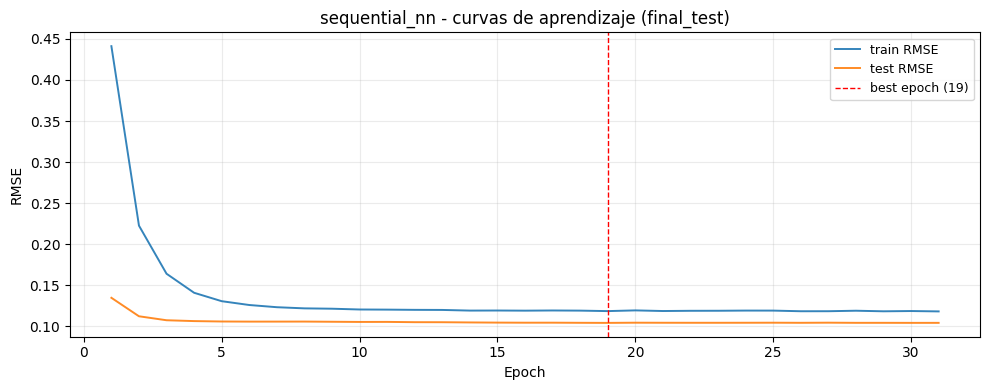

2026-04-18 13:32:25,723 | INFO | src.volatility_models.visualization_utils | Metadata de reentrenamiento guardada: C:\Users\danir\Desktop\TFM - Opciones\options-pricing\src\volatility_models\trained_metadata\retrained_metadata\sequential_nn_final_test_retrained_metadata.json
2026-04-18 13:32:25,761 | INFO | src.volatility_models.visualization_utils | Scaler guardado en: C:\Users\danir\Desktop\TFM - Opciones\options-pricing\src\volatility_models\trained_models\sequential_nn_scaler.joblib
2026-04-18 13:32:25,761 | INFO | src.volatility_models.visualization_utils | Modelo guardado en: C:\Users\danir\Desktop\TFM - Opciones\options-pricing\src\volatility_models\trained_models\sequential_nn.keras


In [10]:
sequential_nn_best_model_metrics_test = Trainer(SequentialNNFamily).retrain_best_params_family(phase=TrainingPhase.FINAL_TEST)

In [ ]:
# Autokeras
sequential_nn_best_model_metrics_test = Trainer(SequentialNNFamily).retrain_best_params_family(phase=TrainingPhase.FINAL_TEST)

2026-04-18 13:34:09,610 | INFO | src.volatility_models.visualization_utils | Resultados del mejor modelo de la familia tras el reentrenamiento con train + val:
                train_mae  train_rmse  train_r2  test_mae  test_rmse   test_r2
retrained_best   0.084637    0.200339 -0.827085  0.056328   0.088602  0.790563


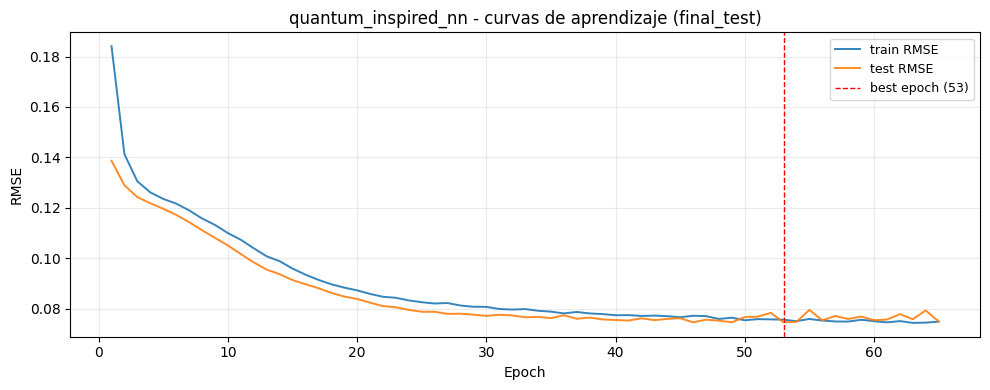

2026-04-18 13:34:09,762 | INFO | src.volatility_models.visualization_utils | Metadata de reentrenamiento guardada: C:\Users\danir\Desktop\TFM - Opciones\options-pricing\src\volatility_models\trained_metadata\retrained_metadata\quantum_inspired_nn_final_test_retrained_metadata.json
2026-04-18 13:34:09,816 | INFO | src.volatility_models.visualization_utils | Scaler guardado en: C:\Users\danir\Desktop\TFM - Opciones\options-pricing\src\volatility_models\trained_models\quantum_inspired_nn_scaler.joblib
2026-04-18 13:34:09,816 | INFO | src.volatility_models.visualization_utils | Modelo guardado en: C:\Users\danir\Desktop\TFM - Opciones\options-pricing\src\volatility_models\trained_models\quantum_inspired_nn.keras


In [11]:
quantum_inspired_nn_best_model_metrics_test = Trainer(QuantumInspiredNNFamily).retrain_best_params_family(phase=TrainingPhase.FINAL_TEST)

# AHORA LO MISMO PERO SOLO CON DATOS ATM

In [ ]:
# Seleccionamos columnas finales
train_df, val_df, test_df = TrainingDataHandler.load_full_features_splitted_data(use_atm=True)
print(f"Total rows adding up all dataframes: {len(train_df)+len(val_df)+len(test_df)}")

In [ ]:
folds = TrainingDataHandler.load_kfolds(use_atm=True)

In [ ]:
linear_models_metrics_table, linear_best_model_name = Trainer(LinearRegressionFamily).run_kfolds_training(use_atm=True)

In [ ]:
random_forest_models_metrics_table, random_forest_best_model_name = Trainer(RandomForestFamily).run_kfolds_training(use_atm=True)

In [ ]:
xgboost_models_metrics_table, xgboost_best_model_name = Trainer(XGBoostFamily).run_kfolds_training(use_atm=True)

In [ ]:
sequential_nn_models_metrics_table, sequential_nn_best_model_name = Trainer(SequentialNNFamily).run_kfolds_training(use_atm=True)

In [ ]:
# Autokeras
sequential_nn_models_metrics_table, sequential_nn_best_model_name = Trainer(SequentialNNFamily).run_kfolds_training(use_atm=True)

In [ ]:
quantum_inspired_nn_models_metrics_table, quantum_inspired_nn_best_model_name = Trainer(QuantumInspiredNNFamily).run_kfolds_training(use_atm=True)

In [ ]:
linear_best_model_metrics = Trainer(LinearRegressionFamily).retrain_best_params_family(use_atm=True)

In [ ]:
random_forest_best_model_metrics = Trainer(RandomForestFamily).retrain_best_params_family(use_atm=True)

In [ ]:
xgboost_best_model_metrics = Trainer(XGBoostFamily).retrain_best_params_family(use_atm=True)

In [ ]:
sequential_nn_best_model_metrics = Trainer(SequentialNNFamily).retrain_best_params_family(use_atm=True)

In [ ]:
# Autokeras
sequential_nn_best_model_metrics = Trainer(SequentialNNFamily).retrain_best_params_family(use_atm=True)

In [ ]:
quantum_inspired_nn_best_model_metrics = Trainer(QuantumInspiredNNFamily).retrain_best_params_family(use_atm=True)

In [ ]:
linear_best_model_metrics_test = Trainer(LinearRegressionFamily).retrain_best_params_family(phase=TrainingPhase.FINAL_TEST, use_atm=True)

In [ ]:
random_forest_best_model_metrics_test = Trainer(RandomForestFamily).retrain_best_params_family(phase=TrainingPhase.FINAL_TEST, use_atm=True)

In [ ]:
xgboost_best_model_metrics_test = Trainer(XGBoostFamily).retrain_best_params_family(phase=TrainingPhase.FINAL_TEST, use_atm=True)

In [ ]:
sequential_nn_best_model_metrics_test = Trainer(SequentialNNFamily).retrain_best_params_family(phase=TrainingPhase.FINAL_TEST, use_atm=True)

In [ ]:
# Autokeras
sequential_nn_best_model_metrics_test = Trainer(SequentialNNFamily).retrain_best_params_family(phase=TrainingPhase.FINAL_TEST, use_atm=True)

In [ ]:
quantum_inspired_nn_best_model_metrics_test = Trainer(QuantumInspiredNNFamily).retrain_best_params_family(phase=TrainingPhase.FINAL_TEST, use_atm=True)

# AUTOKERAS CON Y SIN ATM

In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import keras
from keras import layers, regularizers
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
import keras_tuner as kt
from tqdm.auto import tqdm
import tempfile
import os
import shutil

from src.volatility_models.data_utils import TrainingDataHandler, BASE_FEATURE_COLS, BASE_NUMERIC_FEATURE_COLS
from src.volatility_models.training_utils import TARGET_COLUMN

# Cargar datos
train_df, val_df, _ = TrainingDataHandler.load_full_features_splitted_data(verbose=False)
train_data = pd.concat([train_df, val_df], ignore_index=True)

X_train = train_data[BASE_FEATURE_COLS].to_numpy(dtype=np.float32)
y_train = train_data[TARGET_COLUMN].to_numpy(dtype=np.float32)

# Escalar features numéricas
scaler = StandardScaler()
numeric_indices = tuple(BASE_FEATURE_COLS.index(col) for col in BASE_NUMERIC_FEATURE_COLS if col in BASE_FEATURE_COLS)
X_train_scaled = X_train.copy()
X_train_scaled[:, numeric_indices] = scaler.fit_transform(X_train[:, numeric_indices])

# Definir HyperModel para búsqueda
class MLPRegressionHyperModel(kt.HyperModel):
    def __init__(self, input_dim):
        self.input_dim = input_dim

    def build(self, hp):
        model = keras.Sequential()
        model.add(layers.Input(shape=(self.input_dim,)))
        
        # Hiperparámetros
        num_layers = hp.Int("num_layers", 1, 4)
        for i in range(num_layers):
            units = hp.Int(f"units_{i}", min_value=32, max_value=512, step=32)
            l2_reg = hp.Float(f"l2_reg_{i}", 1e-5, 1e-3, sampling="log")
            dropout = hp.Float(f"dropout_{i}", 0.0, 0.4, step=0.1)
            
            model.add(layers.Dense(units, kernel_regularizer=regularizers.l2(l2_reg)))
            model.add(layers.BatchNormalization())
            model.add(layers.Activation("relu"))
            if dropout > 0:
                model.add(layers.Dropout(dropout))
        
        model.add(layers.Dense(1, activation="linear"))
        
        lr = hp.Float("learning_rate", 1e-5, 1e-2, sampling="log")
        optimizer = keras.optimizers.Adam(learning_rate=lr)
        model.compile(
            optimizer=optimizer,
            loss="mse",
            metrics=["mae", keras.metrics.RootMeanSquaredError(name="rmse")],
        )
        
        return model

    def fit(self, hp, model, x, y, validation_data, epochs, callbacks, **kwargs):
        return model.fit(
            x, y,
            validation_data=validation_data,
            epochs=epochs,
            callbacks=callbacks,
            verbose=0,
            **kwargs
        )

# Tuner con barra de progreso real por trial
class RandomSearchWithTqdm(kt.RandomSearch):
    def search(self, *args, **kwargs):
        self._pbar = tqdm(total=self.oracle.max_trials, desc="KerasTuner Trials", unit="trial")
        try:
            return super().search(*args, **kwargs)
        finally:
            self._pbar.close()
            self._pbar = None

    def run_trial(self, trial, *args, **kwargs):
        result = super().run_trial(trial, *args, **kwargs)
        if getattr(self, "_pbar", None) is not None:
            score = trial.score if trial.score is not None else np.nan
            self._pbar.set_postfix({"val_loss": f"{score:.6f}"})
            self._pbar.update(1)
        return result

# Crear directorio temporal
tmp_dir = tempfile.mkdtemp(prefix="keras_tuner_")

# Configurar búsqueda con RandomSearch (garantiza exactamente N trials)
hypermodel = MLPRegressionHyperModel(input_dim=X_train_scaled.shape[1])

tuner = RandomSearchWithTqdm(
    hypermodel,
    objective="val_loss",
    max_trials=100,
    executions_per_trial=1,
    directory=tmp_dir,
    project_name="mLP_search",
    seed=42,
)

# Split train-val interno
X_fit = X_train_scaled[:int(0.8 * len(X_train_scaled))]
y_fit = y_train[:int(0.8 * len(y_train))]
X_val_inner = X_train_scaled[int(0.8 * len(X_train_scaled)): ]
y_val_inner = y_train[int(0.8 * len(y_train)): ]

# Buscar configuraciones
print("Buscando 100 configuraciones de MLP...")
tuner.search(
    X_fit, y_fit,
    validation_data=(X_val_inner, y_val_inner),
    epochs=200,
    batch_size=256,
    callbacks=[
        EarlyStopping(monitor="val_loss", patience=15, restore_best_weights=True, verbose=0),
        ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=5, min_lr=1e-6, verbose=0),
    ],
)

# Obtener mejor modelo
best_model = tuner.get_best_models(num_models=1)[0]

# Evaluar en todo train
y_pred = best_model.predict(X_train_scaled, verbose=0).flatten()

mae = mean_absolute_error(y_train, y_pred)
mse = mean_squared_error(y_train, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_train, y_pred)

autokeras_best_model_metrics = pd.Series({
    "train_mae": mae,
    "train_mse": mse,
    "train_rmse": rmse,
    "train_r2": r2,
}, name="autokeras_best")

print("\nBúsqueda completada: 100 trials")
print("AutoKeras Best Model Metrics:")
print(autokeras_best_model_metrics)

# Guardar modelo
os.makedirs("trained_models", exist_ok=True)
best_model.save("trained_models/autokeras_best_model.keras")

# Guardar mejor configuración
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
print("\nMejor Configuración (Hiperparámetros):")
print(best_hps.values)

# Limpiar temp
shutil.rmtree(tmp_dir, ignore_errors=True)


In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import keras
from keras import layers, regularizers
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
import keras_tuner as kt
from tqdm.auto import tqdm
import tempfile
import os
import shutil

from src.volatility_models.data_utils import TrainingDataHandler, BASE_FEATURE_COLS, BASE_NUMERIC_FEATURE_COLS
from src.volatility_models.training_utils import TARGET_COLUMN

# Cargar datos ATM
train_df, val_df, _ = TrainingDataHandler.load_full_features_splitted_data(verbose=False, use_atm=True)
train_data = pd.concat([train_df, val_df], ignore_index=True)

X_train = train_data[BASE_FEATURE_COLS].to_numpy(dtype=np.float32)
y_train = train_data[TARGET_COLUMN].to_numpy(dtype=np.float32)

# Escalar features numéricas
scaler = StandardScaler()
numeric_indices = tuple(BASE_FEATURE_COLS.index(col) for col in BASE_NUMERIC_FEATURE_COLS if col in BASE_FEATURE_COLS)
X_train_scaled = X_train.copy()
X_train_scaled[:, numeric_indices] = scaler.fit_transform(X_train[:, numeric_indices])

# Definir HyperModel para búsqueda
class MLPRegressionHyperModel(kt.HyperModel):
    def __init__(self, input_dim):
        self.input_dim = input_dim

    def build(self, hp):
        model = keras.Sequential()
        model.add(layers.Input(shape=(self.input_dim,)))

        # Hiperparámetros
        num_layers = hp.Int("num_layers", 1, 4)
        for i in range(num_layers):
            units = hp.Int(f"units_{i}", min_value=32, max_value=512, step=32)
            l2_reg = hp.Float(f"l2_reg_{i}", 1e-5, 1e-3, sampling="log")
            dropout = hp.Float(f"dropout_{i}", 0.0, 0.4, step=0.1)

            model.add(layers.Dense(units, kernel_regularizer=regularizers.l2(l2_reg)))
            model.add(layers.BatchNormalization())
            model.add(layers.Activation("relu"))
            if dropout > 0:
                model.add(layers.Dropout(dropout))

        model.add(layers.Dense(1, activation="linear"))

        lr = hp.Float("learning_rate", 1e-5, 1e-2, sampling="log")
        optimizer = keras.optimizers.Adam(learning_rate=lr)
        model.compile(
            optimizer=optimizer,
            loss="mse",
            metrics=["mae", keras.metrics.RootMeanSquaredError(name="rmse")],
        )

        return model

    def fit(self, hp, model, x, y, validation_data, epochs, callbacks, **kwargs):
        return model.fit(
            x, y,
            validation_data=validation_data,
            epochs=epochs,
            callbacks=callbacks,
            verbose=0,
            **kwargs
        )

# Tuner con barra de progreso real por trial
class RandomSearchWithTqdm(kt.RandomSearch):
    def search(self, *args, **kwargs):
        self._pbar = tqdm(total=self.oracle.max_trials, desc="KerasTuner Trials ATM", unit="trial")
        try:
            return super().search(*args, **kwargs)
        finally:
            self._pbar.close()
            self._pbar = None

    def run_trial(self, trial, *args, **kwargs):
        result = super().run_trial(trial, *args, **kwargs)
        if getattr(self, "_pbar", None) is not None:
            score = trial.score if trial.score is not None else np.nan
            self._pbar.set_postfix({"val_loss": f"{score:.6f}"})
            self._pbar.update(1)
        return result

# Crear directorio temporal
tmp_dir = tempfile.mkdtemp(prefix="keras_tuner_atm_")

# Configurar búsqueda con RandomSearch (garantiza exactamente N trials)
hypermodel = MLPRegressionHyperModel(input_dim=X_train_scaled.shape[1])

tuner = RandomSearchWithTqdm(
    hypermodel,
    objective="val_loss",
    max_trials=100,
    executions_per_trial=1,
    directory=tmp_dir,
    project_name="mLP_search_atm",
    seed=42,
)

# Split train-val interno
X_fit = X_train_scaled[:int(0.8 * len(X_train_scaled))]
y_fit = y_train[:int(0.8 * len(y_train))]
X_val_inner = X_train_scaled[int(0.8 * len(X_train_scaled)): ]
y_val_inner = y_train[int(0.8 * len(y_train)): ]

# Buscar configuraciones
print("Buscando 100 configuraciones de MLP (ATM)...")
tuner.search(
    X_fit, y_fit,
    validation_data=(X_val_inner, y_val_inner),
    epochs=200,
    batch_size=256,
    callbacks=[
        EarlyStopping(monitor="val_loss", patience=15, restore_best_weights=True, verbose=0),
        ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=5, min_lr=1e-6, verbose=0),
    ],
)

# Obtener mejor modelo
best_model = tuner.get_best_models(num_models=1)[0]

# Evaluar en todo train
y_pred = best_model.predict(X_train_scaled, verbose=0).flatten()

mae = mean_absolute_error(y_train, y_pred)
mse = mean_squared_error(y_train, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_train, y_pred)

autokeras_best_model_metrics_atm = pd.Series({
    "train_mae": mae,
    "train_mse": mse,
    "train_rmse": rmse,
    "train_r2": r2,
}, name="autokeras_best_atm")

print("\nBúsqueda completada: 100 trials")
print("AutoKeras Best Model Metrics (ATM):")
print(autokeras_best_model_metrics_atm)

# Guardar modelo
os.makedirs("trained_models", exist_ok=True)
best_model.save("trained_models/autokeras_best_model_atm.keras")

# Guardar mejor configuración
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
print("\nMejor Configuración ATM (Hiperparámetros):")
print(best_hps.values)

# Limpiar temp
shutil.rmtree(tmp_dir, ignore_errors=True)